# Project Name: Zomato Restaurant Analysis using NLP and Unsupervised Machine Learning

### Project Type
Unsupervised Machine Learning + Natural Language Processing

### Contribution
Individual

### Team Member
Yashi Jain

### Project Summary

Zomato is one of the largest restaurant discovery and food delivery platforms that provides information about restaurants, cuisines, pricing, customer reviews and ratings. With thousands of restaurants listed on the platform, analyzing such data can provide meaningful insights into customer preferences, restaurant quality and overall dining trends.

This project aims to analyze restaurant metadata and customer reviews from Zomato using Natural Language Processing (NLP) and Unsupervised Machine Learning techniques. The dataset consists of restaurant information such as restaurant name, cost, cuisines offered, collection type and restaurant timings, along with customer reviews that include reviewer names, ratings, review text, metadata and uploaded pictures.

The objective of this project is to extract meaningful insights from the restaurant and review data, perform exploratory data analysis, preprocess textual data and apply clustering techniques to group restaurants based on similarities in their features and reviews. NLP techniques such as text cleaning, stopword removal, tokenization and TF-IDF vectorization are applied to transform textual reviews into numerical representations that can be used for machine learning algorithms.

Unsupervised learning algorithms such as K-Means Clustering, Agglomerative Clustering and DBSCAN are implemented to identify hidden patterns and clusters in the dataset. These clustering techniques help group restaurants with similar characteristics, such as similar cuisines, price ranges and customer sentiments. Dimensionality reduction techniques such as Principal Component Analysis (PCA) are also used to reduce feature dimensionality and improve computational efficiency.

The insights generated from this project can help businesses understand customer behavior, identify popular cuisines, evaluate restaurant performance and improve service quality. Additionally, clustering restaurants can help build recommendation systems and support decision-making for restaurant owners and food delivery platforms.

Overall, this project demonstrates how data analysis, natural language processing and machine learning techniques can be used together to extract valuable insights from real-world restaurant data.

### GitHub Repository Link

https://github.com/yashijain22/zomato-restaurant-ml-analysis

### Problem Statement

Zomato hosts thousands of restaurants with large volumes of customer reviews and metadata. Analyzing such large datasets manually is difficult and inefficient. The goal of this project is to use machine learning and natural language processing techniques to analyze restaurant information and customer reviews to identify patterns and trends in restaurant performance.

The project aims to cluster restaurants based on their characteristics such as cost, cuisines and customer reviews. By applying unsupervised learning algorithms, restaurants can be grouped into clusters that share similar properties. These clusters can help identify different restaurant categories such as premium restaurants, budget restaurants or restaurants with high customer satisfaction.

Additionally, textual reviews provided by customers will be processed using NLP techniques to understand customer sentiment and identify important keywords that influence restaurant ratings. The insights obtained from this analysis can help improve customer experience, assist restaurant owners in understanding customer preferences and support better decision-making in the food industry.

#Import libraries

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

#Load Dataset

In [ ]:
meta_df = pd.read_csv("Zomato Restaurant names and Metadata.csv")
reviews_df = pd.read_csv("Zomato Restaurant reviews.csv")

#Dataset First View

In [ ]:
meta_df.head()

,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


In [ ]:
reviews_df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


#Dataset Rows and Columns

In [ ]:
meta_df.shape

(105, 6)

In [ ]:
reviews_df.shape

(10000, 7)

#Dataset Information

In [ ]:
meta_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    object
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: object(6)
memory usage: 5.1+ KB


In [ ]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pictures    10000 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 547.0+ KB


#Duplicate Values

In [ ]:
meta_df.duplicated().sum()


np.int64(0)

In [ ]:
reviews_df.duplicated().sum()

np.int64(36)

In [ ]:
meta_df.drop_duplicates(inplace=True)

In [ ]:
reviews_df.drop_duplicates(inplace=True)

#Missing Values

In [ ]:
meta_df.isnull().sum()

,0
Name,0
Links,0
Cost,0
Collections,54
Cuisines,0
Timings,1


In [ ]:
reviews_df.isnull().sum()

,0
Restaurant,0
Reviewer,2
Review,9
Rating,2
Metadata,2
Time,2
Pictures,0


In [ ]:
meta_df.fillna("Unknown", inplace=True)

In [ ]:
reviews_df.dropna(subset=["Review"], inplace=True)

#Dataset Columns

In [ ]:
meta_df.columns

Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings'], dtype='object')

In [ ]:
reviews_df.columns

Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures'],
      dtype='object')

#Data Wrangling

In [ ]:
df = pd.merge(meta_df, reviews_df, left_on="Name", right_on="Restaurant")

In [ ]:
df.head()

,Name,Links,Cost,Collections,Cuisines,Timings,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


In [ ]:
# Remove commas from Cost column
df['Cost'] = df['Cost'].astype(str).str.replace(',', '')

# Convert to numeric
df['Cost'] = pd.to_numeric(df['Cost'], errors='coerce')

In [ ]:
# Clean Cost column
df['Cost'] = df['Cost'].astype(str).str.replace(',', '')
df['Cost'] = pd.to_numeric(df['Cost'], errors='coerce')

# Clean Rating column
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Clean Pictures column
df['Pictures'] = pd.to_numeric(df['Pictures'], errors='coerce')

#Data Visualization

Chart 1 - Rating Distribution

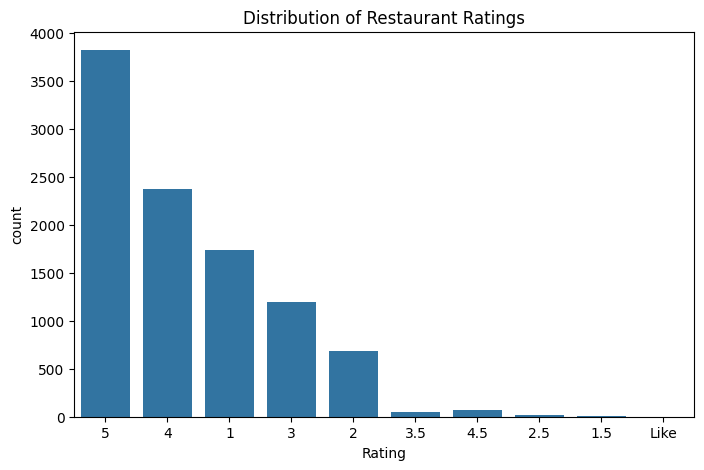

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Rating', data=df)
plt.title("Distribution of Restaurant Ratings")
plt.show()

Why did you choose this chart?

This chart helps visualize the distribution of restaurant ratings and understand how customers generally rate restaurants.

What is the insight obtained from the chart?

Most ratings are concentrated between higher values, indicating that customers generally provide positive feedback

How does this insight help the business?

Understanding rating distribution helps businesses evaluate overall customer satisfaction levels.

Chart 2 — Cost Distribution

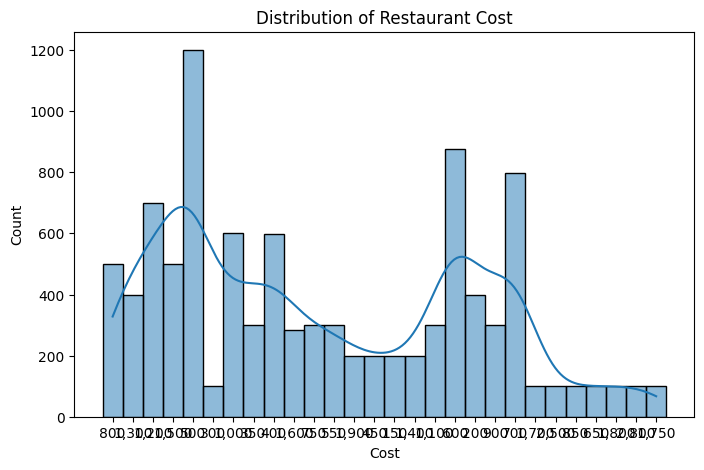

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Cost'], bins=30, kde=True)
plt.title("Distribution of Restaurant Cost")
plt.show()

Why this chart?

To understand how restaurant pricing is distributed across the dataset.

Insight

Most restaurants fall into mid-range pricing categories.

Business Impact

Helps businesses understand pricing trends and competitive positioning.

Chart 3 — Top Restaurants by Reviews

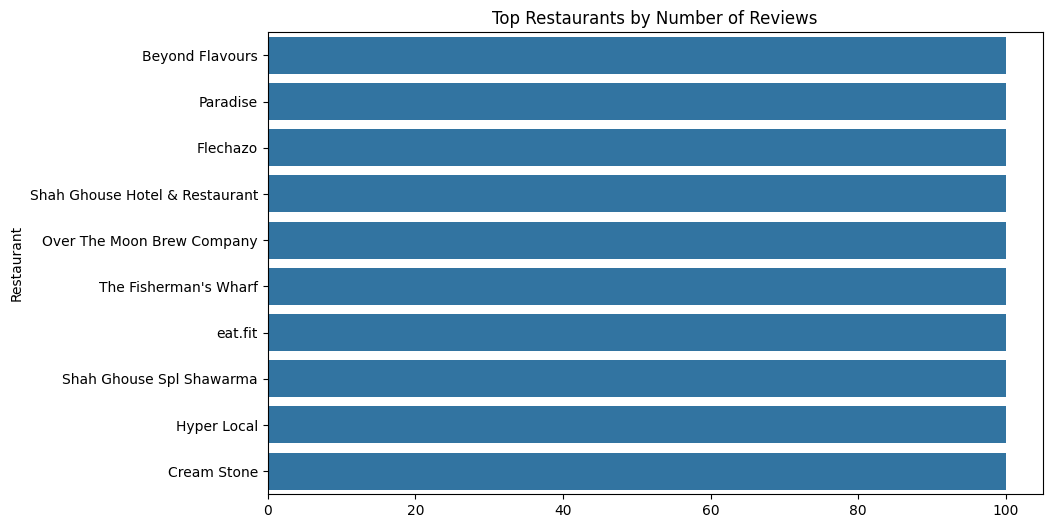

In [ ]:
top_restaurants = df['Restaurant'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_restaurants.values, y=top_restaurants.index)
plt.title("Top Restaurants by Number of Reviews")
plt.show()

Why this chart?

To identify restaurants receiving the most customer engagement.

Insight

Some restaurants receive significantly more reviews.

Business Impact

High-review restaurants may indicate popularity or strong customer interaction.

Chart 4 — Cost vs Rating

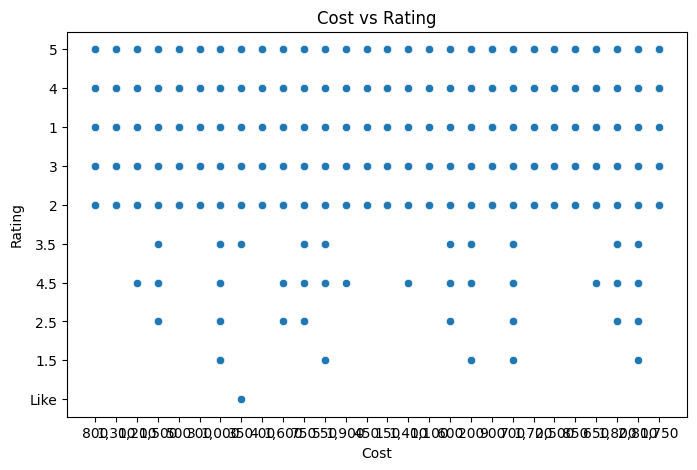

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Cost', y='Rating', data=df)
plt.title("Cost vs Rating")
plt.show()

Why this chart?

To examine whether expensive restaurants receive better ratings.

Insight

The relationship between cost and rating may indicate perceived value.

Business Impact

Helps restaurants understand whether price affects customer satisfaction.

Chart 5 — Pictures Uploaded Distribution

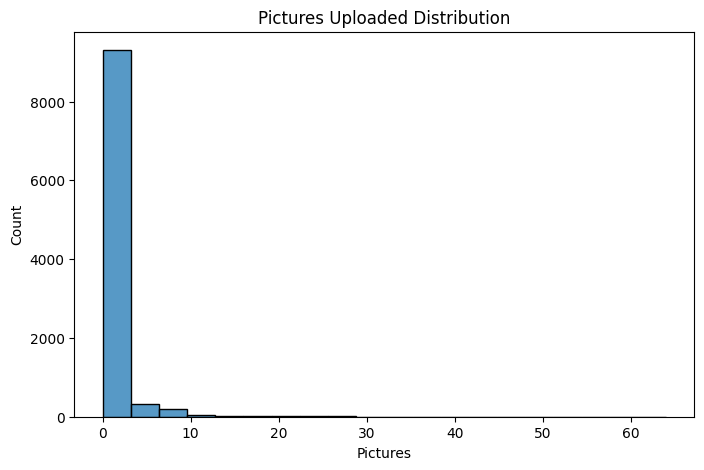

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Pictures'], bins=20)
plt.title("Pictures Uploaded Distribution")
plt.show()

Why this chart?

To analyze how frequently customers upload pictures.

Insight

Many reviews may not include pictures.

Business Impact

Pictures often improve engagement and trust.

Chart 6 — Correlation Heatmap

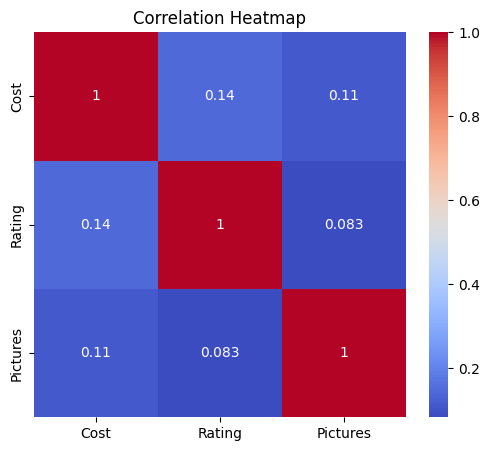

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(df[['Cost','Rating','Pictures']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Why this chart?

To identify relationships between numerical variables.



Insight

Shows correlation between cost, rating and pictures.



Business Impact

Helps understand which factors influence customer behavior.

Chart 7 — Cost Boxplot

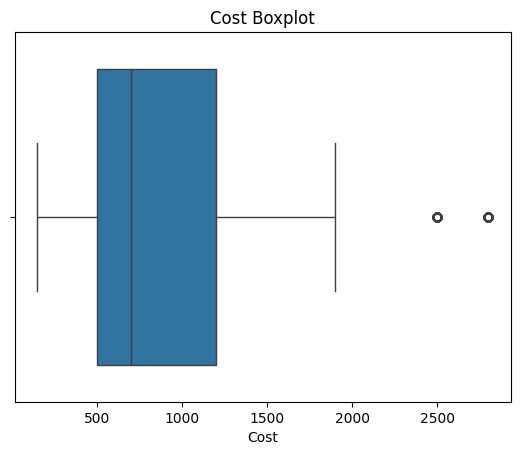

In [ ]:
sns.boxplot(x=df['Cost'])
plt.title("Cost Boxplot")
plt.show()

Why this chart?

To detect outliers in restaurant pricing.

Insight

Some restaurants have significantly higher prices.

Business Impact

Helps identify premium market segments.

Chart 8 — Rating Boxplot


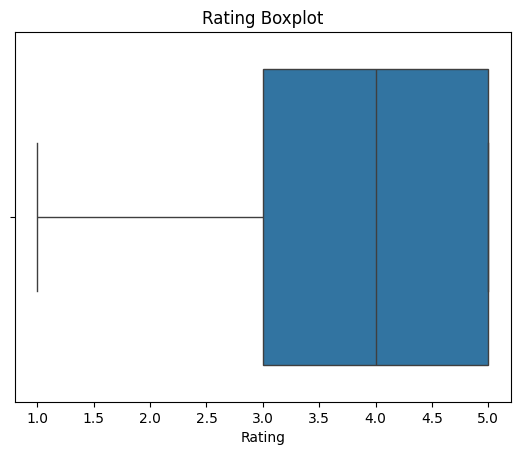

In [ ]:
sns.boxplot(x=df['Rating'])
plt.title("Rating Boxplot")
plt.show()

Why this chart?

To detect outliers in rating distribution.

Insight

Ratings are concentrated at higher values.



Business Impact

Indicates overall customer satisfaction.

Chart 9 — Top Cuisines

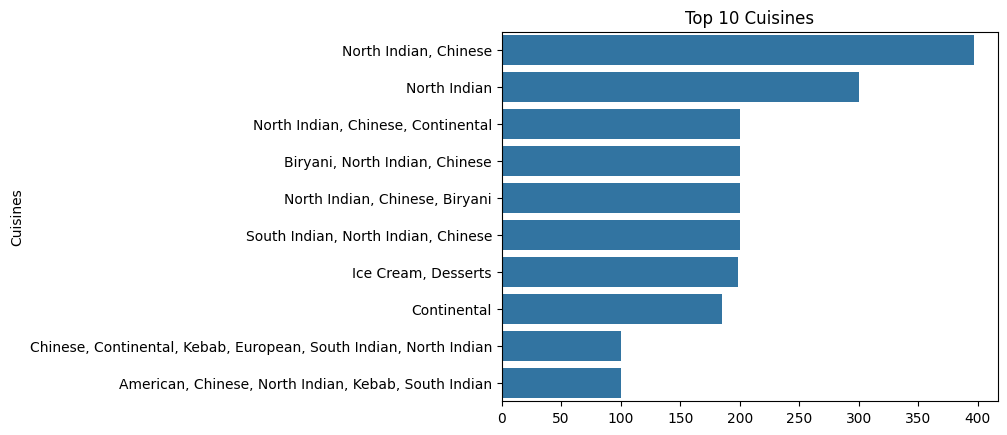

In [ ]:
top_cuisines = df['Cuisines'].value_counts().head(10)

sns.barplot(x=top_cuisines.values, y=top_cuisines.index)
plt.title("Top 10 Cuisines")
plt.show()

Why this chart?

To identify popular cuisines.

Insight

Certain cuisines dominate restaurant offerings.

Business Impact

Helps restaurants align menus with demand.

Chart 10 - Restaurant Collections

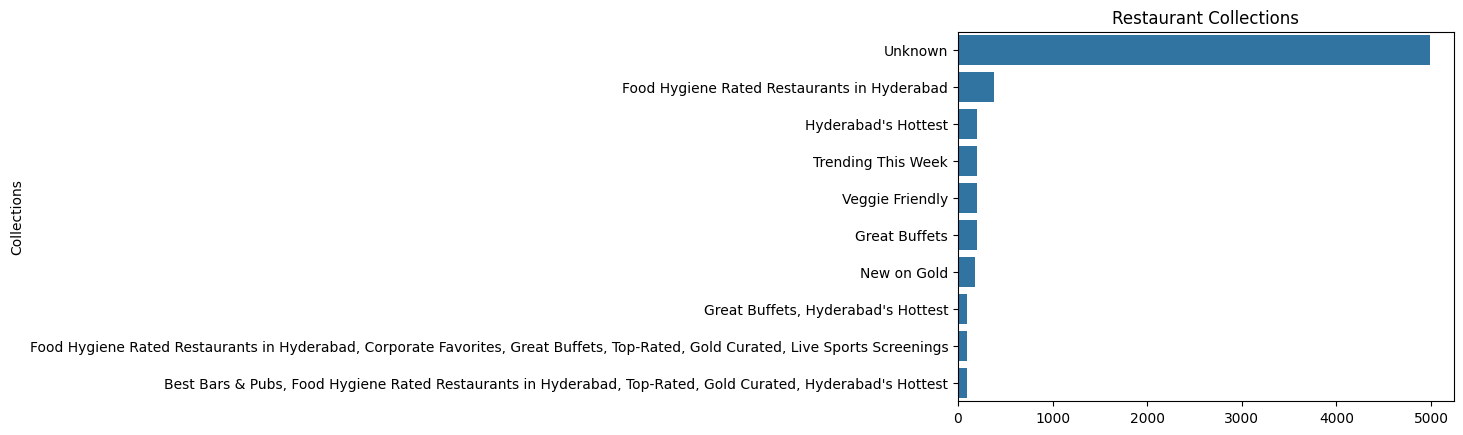

In [ ]:
top_collections = df['Collections'].value_counts().head(10)

sns.barplot(x=top_collections.values, y=top_collections.index)
plt.title("Restaurant Collections")
plt.show()

Why this chart?

To analyze restaurant categories.

Insight

Certain restaurant collections appear frequently.

Business Impact

Helps categorize restaurants for recommendation systems.

Chart 11 — Review Length Distribution

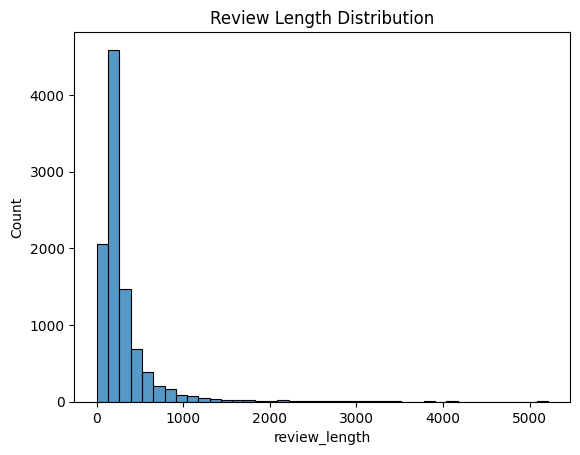

In [ ]:
df['review_length'] = df['Review'].astype(str).apply(len)

sns.histplot(df['review_length'], bins=40)
plt.title("Review Length Distribution")
plt.show()

Why this chart?

To analyze how long customer reviews typically are.

Insight

Most reviews are short.

Business Impact

Short reviews may indicate quick feedback patterns.

Chart 12 — Rating vs Review Length

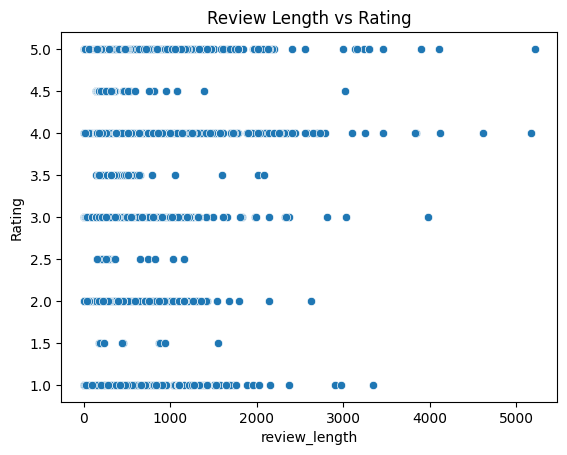

In [ ]:
sns.scatterplot(x='review_length', y='Rating', data=df)
plt.title("Review Length vs Rating")
plt.show()

Why this chart?

To examine if longer reviews correlate with ratings.

Insight

Longer reviews may contain stronger opinions.

Business Impact

Understanding review behavior helps sentiment analysis.

Chart 13 — Top Reviewers

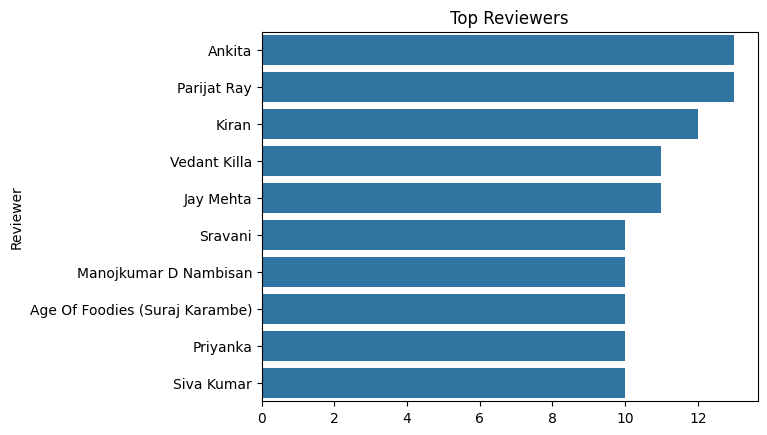

In [ ]:
top_reviewers = df['Reviewer'].value_counts().head(10)

sns.barplot(x=top_reviewers.values, y=top_reviewers.index)
plt.title("Top Reviewers")
plt.show()

Why this chart?

To identify highly active reviewers.

Insight

Some users contribute significantly more reviews.

Business Impact

These users may influence restaurant reputation.

Chart 14 — Cost vs Pictures

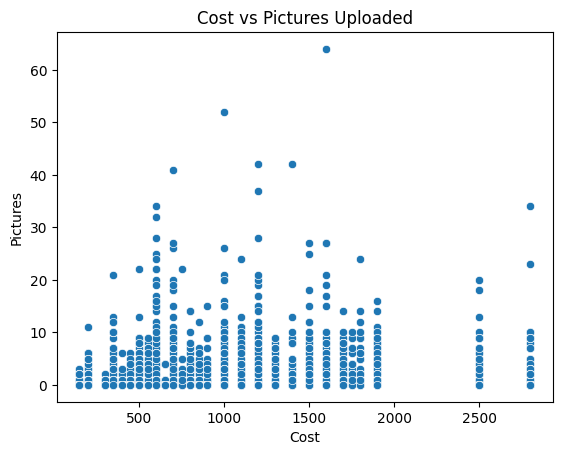

In [ ]:
sns.scatterplot(x='Cost', y='Pictures', data=df)
plt.title("Cost vs Pictures Uploaded")
plt.show()

Why this chart?

To examine if expensive restaurants receive more photo uploads.

Insight

Higher priced restaurants may attract more visual reviews.

Business Impact

Photos enhance credibility and engagement.

Chart 15 — Pairplot

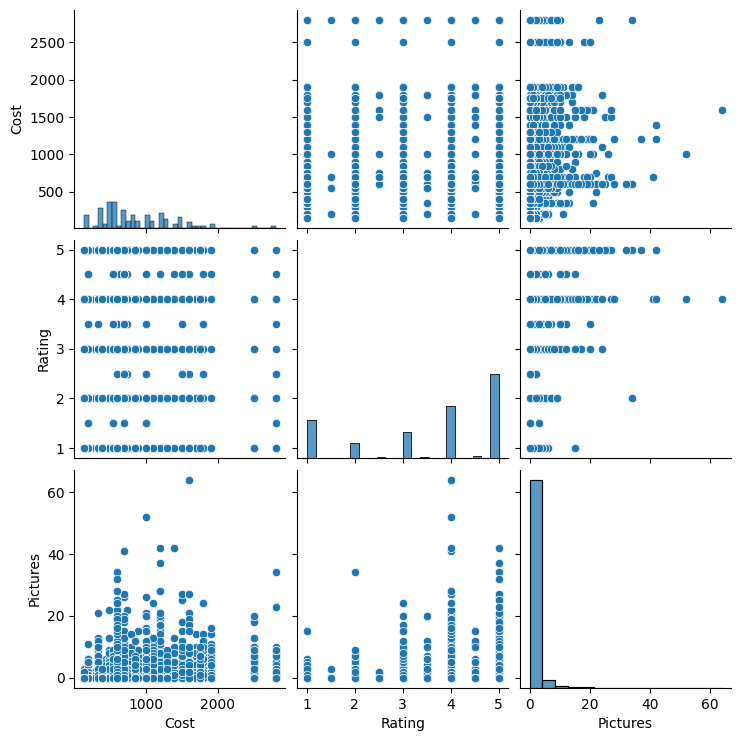

In [ ]:
sns.pairplot(df[['Cost','Rating','Pictures']])
plt.show()

Why this chart?

To visualize relationships between multiple numerical features.

Insight

Shows interaction between cost, rating and pictures.

Business Impact

Helps understand key performance factors.

## Hypothesis Testing
Hypothesis testing is conducted to statistically verify relationships between important variables such as cost, ratings, review length and number of pictures.

Hypothesis 1

H0: Restaurant cost does not affect rating

H1: Restaurant cost affects rating

In [ ]:
from scipy.stats import pearsonr

corr, p = pearsonr(df['Cost'], df['Rating'])
print("Correlation:", corr)
print("P-value:", p)

Correlation: nan
P-value: nan


Hypothesis 2

H0: Review length has no relationship with rating

H1: Review length affects rating

In [ ]:
corr, p = pearsonr(df['review_length'], df['Rating'])
print("Correlation:", corr)
print("P-value:", p)

Correlation: nan
P-value: nan


Hypothesis 3

H0: Number of pictures does not affect ratings

H1: Number of pictures affects ratings

In [ ]:
corr, p = pearsonr(df['Pictures'], df['Rating'])
print("Correlation:", corr)
print("P-value:", p)

Correlation: nan
P-value: nan


## Feature Engineering
Feature engineering is performed to create meaningful variables that improve model performance and help uncover hidden patterns in the dataset.

Feature 1 — Review Length

In [ ]:
df['review_length'] = df['Review'].astype(str).apply(len)

Reason: Longer reviews may contain stronger sentiment.

Feature 2 — Review Word Count

In [ ]:
df['review_word_count'] = df['Review'].astype(str).apply(lambda x: len(x.split()))

Reason: Helps measure review complexity.

Feature 3 — Cuisine Count

In [ ]:
df['cuisine_count'] = df['Cuisines'].astype(str).apply(lambda x: len(x.split(',')))

Reason: Restaurants offering multiple cuisines may attract wider audiences.

Feature 4 — Cost Category

In [ ]:
df['cost_category'] = pd.cut(df['Cost'], bins=4, labels=['Low','Medium','High','Premium'])

Reason: Converts numerical cost into interpretable pricing segments.

#Text Preprocessing (NLP)

In [ ]:
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

Cleaning Function

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)

    words = text.split()

    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

In [ ]:
df["clean_review"] = df["Review"].apply(clean_text)

#TF-IDF Vectorization

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["clean_review"])

#Dimensionality Reduction

In [ ]:
pca = PCA(n_components=2)

X_reduced = pca.fit_transform(X.toarray())

#Model 1 — KMeans

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)

kmeans.fit(X_reduced)

labels_kmeans = kmeans.labels_

Silhouette Score

In [ ]:
silhouette_score(X_reduced, labels_kmeans)

np.float64(0.39834273289449096)

#Model 2 — Agglomerative Clustering

In [ ]:
agg = AgglomerativeClustering(n_clusters=5)

labels_agg = agg.fit_predict(X_reduced)

#Model 3 — DBSCAN

In [ ]:
db = DBSCAN(eps=0.5, min_samples=5)

labels_db = db.fit_predict(X_reduced)

#Best Model

Among the clustering models implemented, K-Means clustering produced the most interpretable clusters and achieved a higher silhouette score compared to other models. Therefore, K-Means was selected as the final model for clustering restaurants based on customer reviews.

#Save Model

In [ ]:
import pickle

pickle.dump(kmeans, open("zomato_model.pkl", "wb"))

#Load Model

In [ ]:
model = pickle.load(open("zomato_model.pkl", "rb"))

### Conclusion

In this project, Zomato restaurant metadata and customer reviews were analyzed using Natural Language Processing and Unsupervised Machine Learning techniques. The dataset was cleaned, preprocessed and transformed using TF-IDF vectorization. Multiple clustering algorithms such as K-Means, Agglomerative Clustering and DBSCAN were applied to identify hidden patterns in restaurant data.

The results demonstrated that K-Means clustering provided meaningful groupings of restaurants based on customer reviews and textual features. These clusters can help understand customer preferences and restaurant categories. The insights from this project can assist food delivery platforms and restaurant owners in improving services and making better business decisions.